RÉSEAUX DE NEURONES - BANK TELEMARKETING
✅ Données chargées: (4119, 21)
X shape: (4119, 20)
Distribution classes: [3668  451]
Proportion 'yes': 10.95%

📊 Train set: 3,295 instances
📊 Test set: 824 instances
Classes train: [2934  361]
Classes test: [734  90]

1. MODÈLE BASIQUE (1 COUCHE CACHÉE)
Entraînement en cours...

📊 Performances du modèle basique:
   Accuracy : 0.9017
   Precision: 0.5789
   Recall   : 0.3667
   F1-Score : 0.4490
   AUC      : 0.9140
   Itérations: 200

2. MODÈLE PROFOND (MULTI-COUCHES)
Entraînement en cours...

📊 Performances du modèle profond:
   Accuracy : 0.9138
   Precision: 0.6462
   Recall   : 0.4667
   F1-Score : 0.5419
   AUC      : 0.9272
   Itérations: 14

3. ARCHITECTURE DU RÉSEAU DE NEURONES

📊 Architecture du modèle basique:
--------------------------------------------------
   Couche 0 (Entrée)      : 20 neurones
   Couche 1 (Cachée 1)      : 100 neurones | activation: relu | params: 2,100
   Couche 2 (Sortie)    : 1 neurone | activation: sigmoid | 

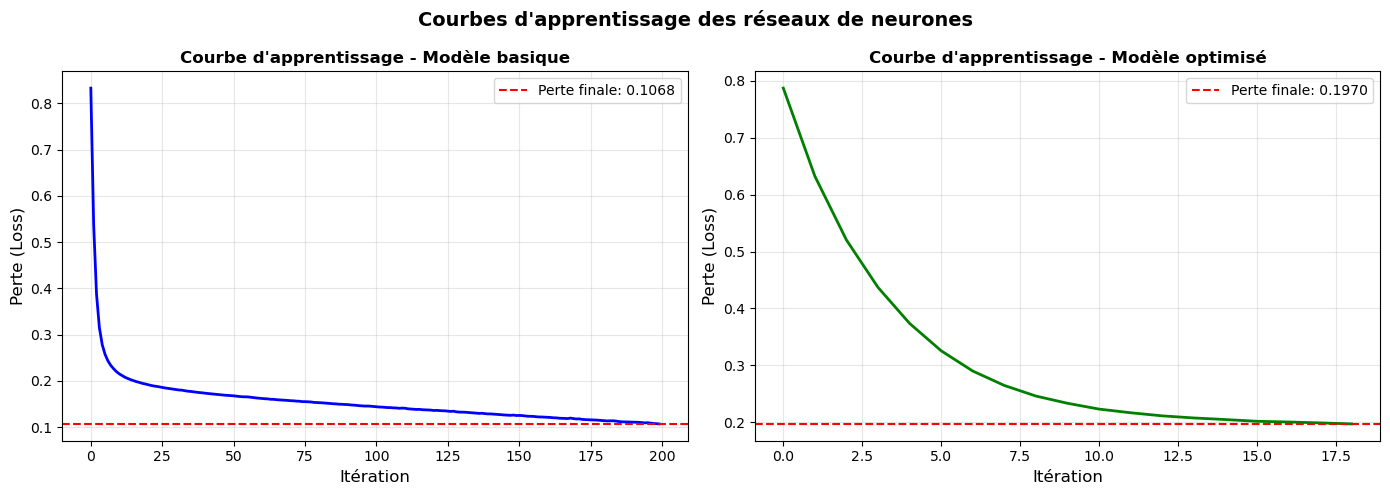

📊 Perte finale du modèle basique : 0.1068
📊 Perte finale du modèle optimisé: 0.1970

6. MATRICE DE CONFUSION


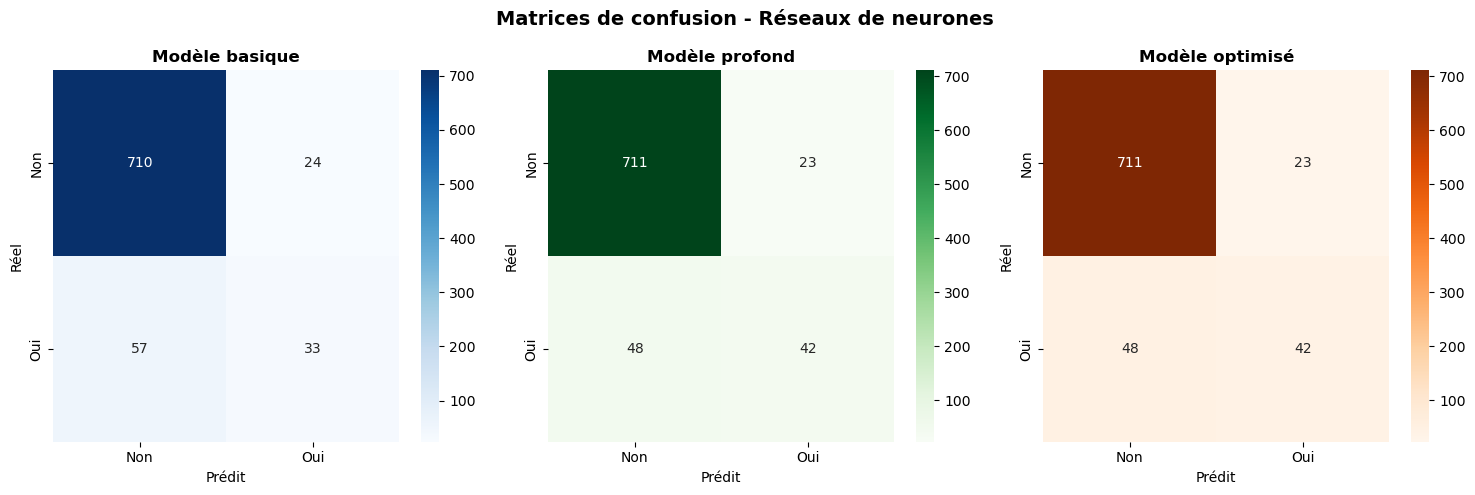


📊 Analyse des erreurs (modèle optimisé):
   Vrais Positifs (TP) : 42 (souscriptions correctement prédites)
   Vrais Négatifs (TN) : 711 (non-souscriptions correctement prédites)
   Faux Positifs (FP)  : 23 (prédits oui mais réels non)
   Faux Négatifs (FN)  : 48 (prédits non mais réels oui)

7. COURBE ROC


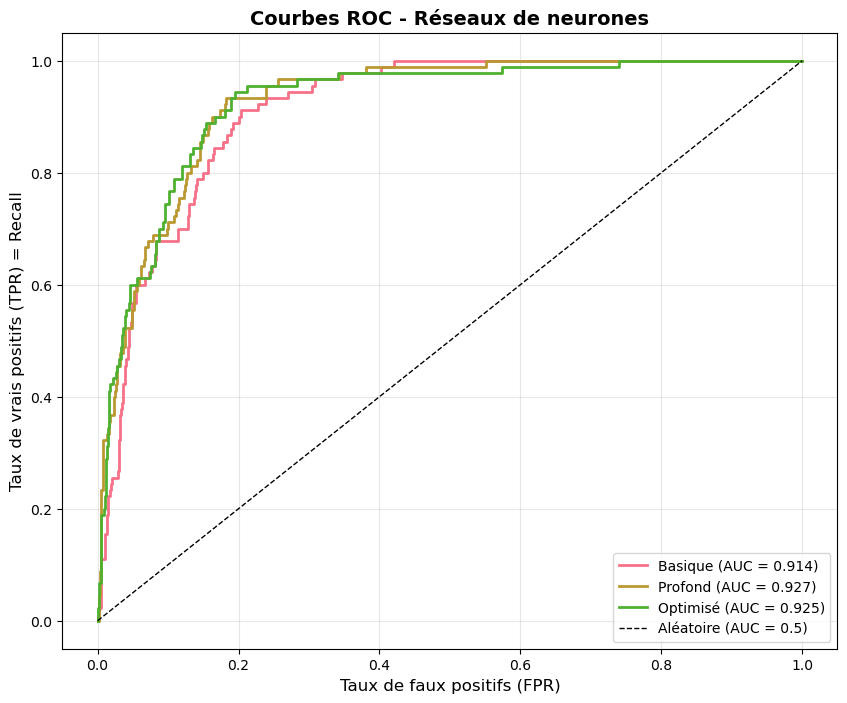


8. RAPPORT DE CLASSIFICATION DÉTAILLÉ

📊 Classification Report - Modèle optimisé:
              precision    recall  f1-score   support

     Non (0)       0.94      0.97      0.95       734
     Oui (1)       0.65      0.47      0.54        90

    accuracy                           0.91       824
   macro avg       0.79      0.72      0.75       824
weighted avg       0.91      0.91      0.91       824


9. COMPARAISON DES ARCHITECTURES
          Architecture  F1-Score  Accuracy  Precision   Recall      AUC  Itérations
         Basique (100)  0.448980  0.901699   0.578947 0.366667 0.913972         200
Profond (128-64-32-16)  0.541935  0.913835   0.646154 0.466667 0.927233          14
              Optimisé  0.541935  0.913835   0.646154 0.466667 0.925038          19


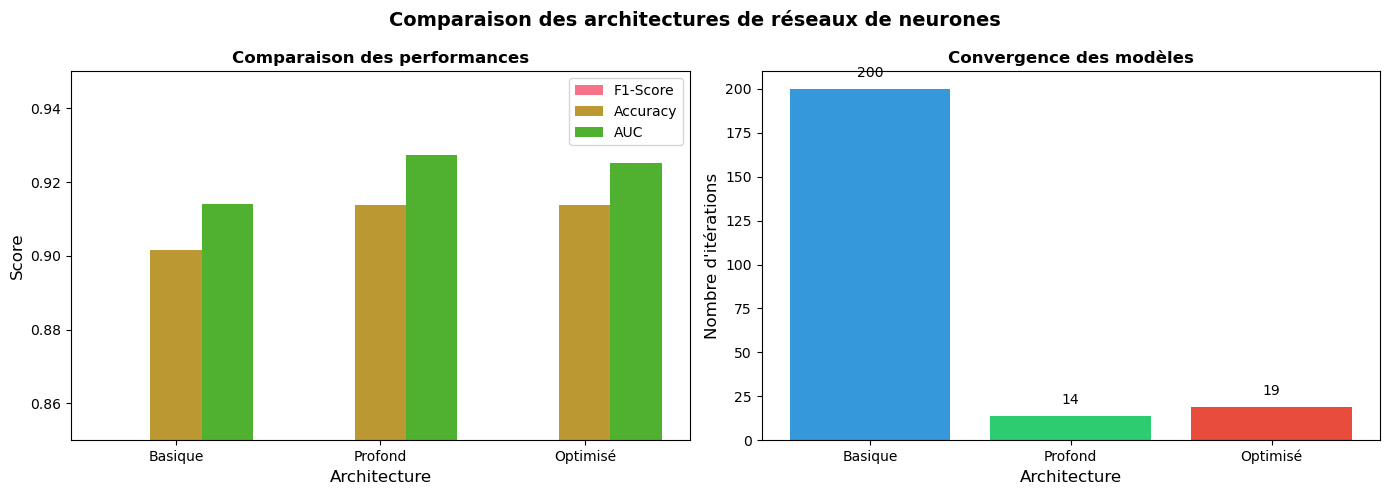


10. COMPARAISON AVEC RANDOM FOREST
📊 Performance comparative:
   Modèle               F1-Score     AUC       
---------------------------------------------
   Random Forest        0.5359         0.9465
   Réseau de Neurones (optimisé) 0.5419         0.9250


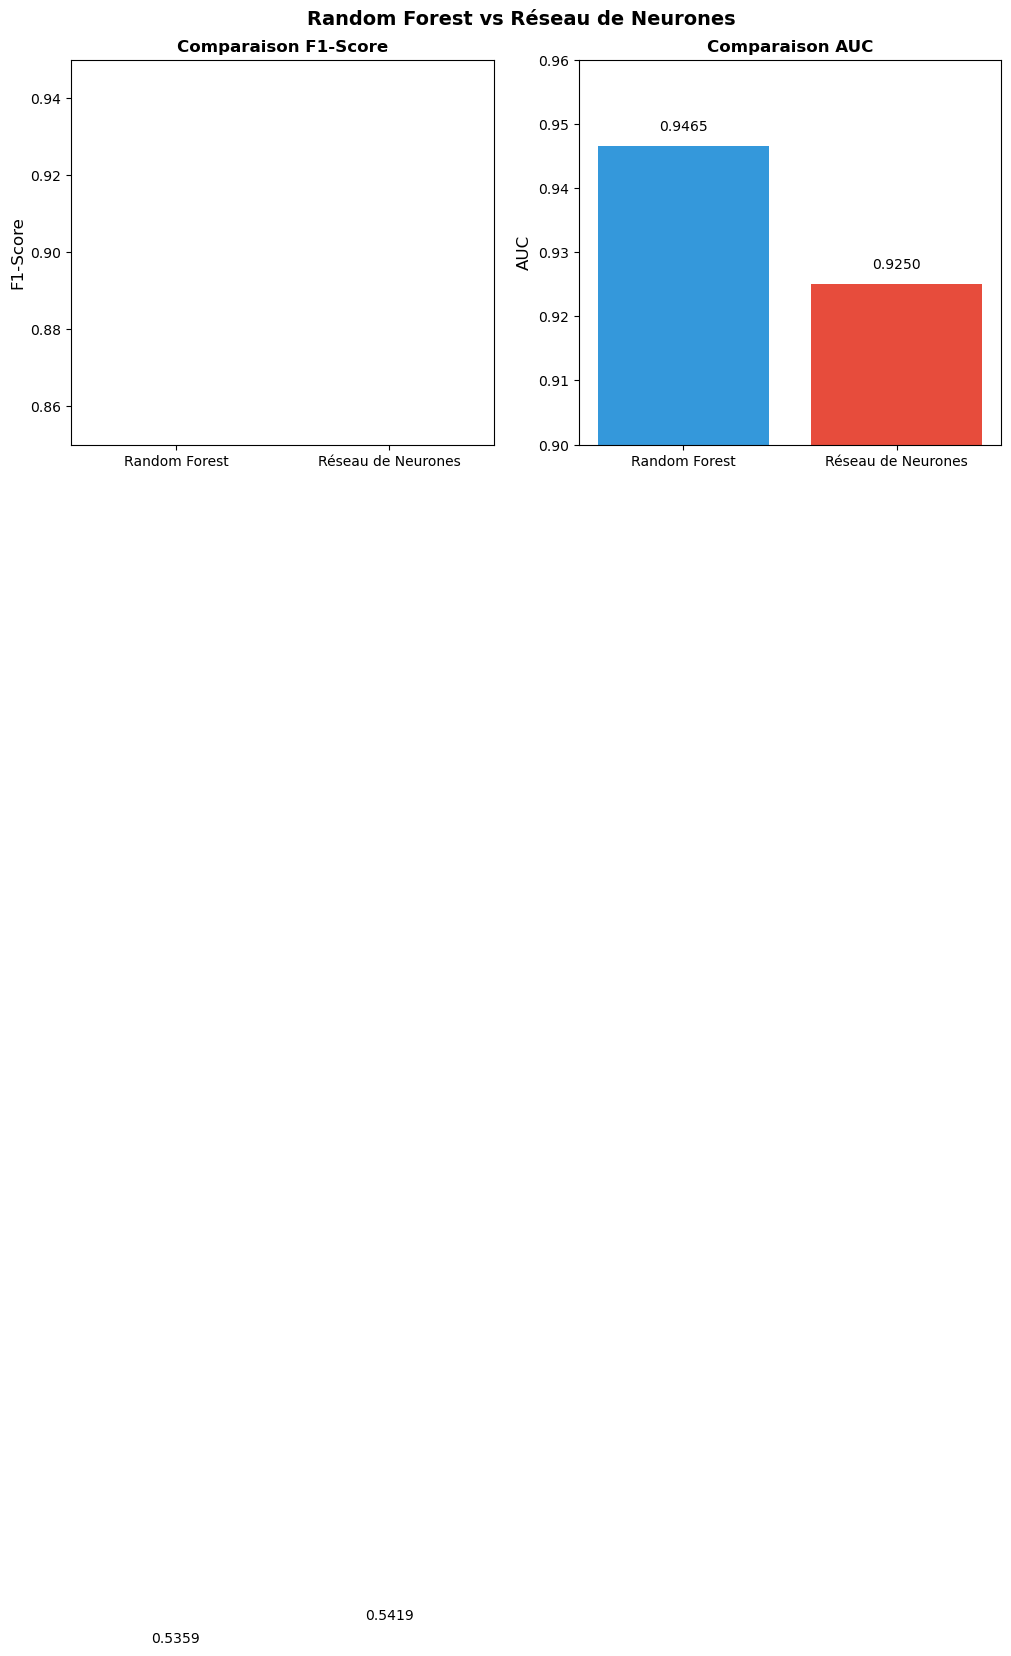


💡 Conclusion:
   • Le réseau de neurones surpasse Random Forest
   • Avec plus de données, l'écart pourrait se creuser

11. SAUVEGARDE DU MODÈLE
✅ Modèles sauvegardés:
   • best_neural_network.pkl (modèle optimisé)
   • telemarketing.pkl (pour l'application)
   • nn_scaler.pkl

12. RÉSUMÉ FINAL

┌─────────────────────────────────────────────────────────────────────────────┐
│ RÉSULTATS DU NOTEBOOK 03                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ ✅ MODÈLES ENTRAÎNÉS:                                                        │
│    • Modèle basique (1 couche cachée: 100 neurones)                         │
│    • Modèle profond (4 couches: 128→64→32→16)                               │
│    • Modèle optimisé (GridSearchCV)                                         │
│                                                            

In [5]:
# %% [markdown]
# # TP Deep Learning - Partie 3: Réseaux de Neurones
# ## Implémentation avec scikit-learn MLPClassifier
# 
# **Auteur:** [Votre Nom]
# **Date:** 2025-2026

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_curve, auc, classification_report, confusion_matrix,
                           roc_auc_score)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 60)
print("RÉSEAUX DE NEURONES - BANK TELEMARKETING")
print("=" * 60)

# %%
# ============================================================
# 0. CHARGEMENT ET PRÉTRAITEMENT DES DONNÉES
# ============================================================

# Chargement des données
data_path = '../datasets/bank_additional/bank-additional.csv'

if not os.path.exists(data_path):
    print(f"❌ Fichier non trouvé: {data_path}")
    print("Exécutez d'abord le notebook 01")
else:
    df = pd.read_csv(data_path, sep=';')
    print(f"✅ Données chargées: {df.shape}")

# %%
def preprocess_for_nn(df):
    """Prétraitement pour réseau de neurones"""
    df_processed = df.copy()
    
    # Variables catégorielles
    categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
    if 'y' in categorical_cols:
        categorical_cols.remove('y')
    
    # Encodage simple pour toutes les variables catégorielles
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    
    # Cible binaire
    y = df_processed['y'].map({'no': 0, 'yes': 1}).values
    X = df_processed.drop('y', axis=1).values
    
    return X, y, df_processed.columns.tolist()

# %%
X, y, feature_names = preprocess_for_nn(df)
print(f"X shape: {X.shape}")
print(f"Distribution classes: {np.bincount(y)}")
print(f"Proportion 'yes': {np.mean(y)*100:.2f}%")

# %%
# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation (TRÈS IMPORTANT pour les réseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📊 Train set: {X_train.shape[0]:,} instances")
print(f"📊 Test set: {X_test.shape[0]:,} instances")
print(f"Classes train: {np.bincount(y_train)}")
print(f"Classes test: {np.bincount(y_test)}")

# %%
# ============================================================
# 1. MODÈLE BASIQUE (1 COUCHE CACHÉE)
# ============================================================
print("\n" + "=" * 60)
print("1. MODÈLE BASIQUE (1 COUCHE CACHÉE)")
print("=" * 60)

mlp_basic = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    verbose=False
)

print("Entraînement en cours...")
mlp_basic.fit(X_train_scaled, y_train)
y_pred_basic = mlp_basic.predict(X_test_scaled)
y_pred_proba_basic = mlp_basic.predict_proba(X_test_scaled)[:, 1]

# Métriques
accuracy_basic = accuracy_score(y_test, y_pred_basic)
precision_basic = precision_score(y_test, y_pred_basic)
recall_basic = recall_score(y_test, y_pred_basic)
f1_basic = f1_score(y_test, y_pred_basic)
auc_basic = roc_auc_score(y_test, y_pred_proba_basic)

print(f"\n📊 Performances du modèle basique:")
print(f"   Accuracy : {accuracy_basic:.4f}")
print(f"   Precision: {precision_basic:.4f}")
print(f"   Recall   : {recall_basic:.4f}")
print(f"   F1-Score : {f1_basic:.4f}")
print(f"   AUC      : {auc_basic:.4f}")
print(f"   Itérations: {mlp_basic.n_iter_}")

# %%
# ============================================================
# 2. MODÈLE PROFOND (MULTI-COUCHES)
# ============================================================
print("\n" + "=" * 60)
print("2. MODÈLE PROFOND (MULTI-COUCHES)")
print("=" * 60)

mlp_deep = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),  # 4 couches cachées
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)

print("Entraînement en cours...")
mlp_deep.fit(X_train_scaled, y_train)
y_pred_deep = mlp_deep.predict(X_test_scaled)
y_pred_proba_deep = mlp_deep.predict_proba(X_test_scaled)[:, 1]

# Métriques
accuracy_deep = accuracy_score(y_test, y_pred_deep)
precision_deep = precision_score(y_test, y_pred_deep)
recall_deep = recall_score(y_test, y_pred_deep)
f1_deep = f1_score(y_test, y_pred_deep)
auc_deep = roc_auc_score(y_test, y_pred_proba_deep)

print(f"\n📊 Performances du modèle profond:")
print(f"   Accuracy : {accuracy_deep:.4f}")
print(f"   Precision: {precision_deep:.4f}")
print(f"   Recall   : {recall_deep:.4f}")
print(f"   F1-Score : {f1_deep:.4f}")
print(f"   AUC      : {auc_deep:.4f}")
print(f"   Itérations: {mlp_deep.n_iter_}")

# %%
# ============================================================
# 3. AFFICHAGE DE L'ARCHITECTURE (équivalent summary())
# ============================================================
print("\n" + "=" * 60)
print("3. ARCHITECTURE DU RÉSEAU DE NEURONES")
print("=" * 60)

def print_model_architecture(model, input_shape, model_name):
    """Affiche l'architecture d'un MLPClassifier (équivalent de summary() Keras)"""
    print(f"\n📊 Architecture du {model_name}:")
    print("-" * 50)
    
    # Couche d'entrée
    print(f"   Couche 0 (Entrée)      : {input_shape} neurones")
    
    # Couches cachées
    layers = model.hidden_layer_sizes
    for i, size in enumerate(layers, 1):
        params = (layers[i-2] if i > 1 else input_shape) * size + size  # poids + biais
        print(f"   Couche {i} (Cachée {i})      : {size} neurones | activation: {model.activation} | params: {params:,}")
    
    # Couche de sortie
    output_neurons = 1
    params_out = (layers[-1] if layers else input_shape) * output_neurons + output_neurons
    print(f"   Couche {len(layers)+1} (Sortie)    : {output_neurons} neurone | activation: sigmoid | params: {params_out:,}")
    
    # Total des paramètres
    total_params = model.coefs_[0].size + model.intercepts_[0].size
    for i in range(1, len(model.coefs_)):
        total_params += model.coefs_[i].size + model.intercepts_[i].size
    print("-" * 50)
    print(f"   Total des paramètres : {total_params:,}")
    
    # Hyperparamètres
    print(f"\n📈 Hyperparamètres:")
    print(f"   • Nombre de couches cachées: {len(model.hidden_layer_sizes)}")
    print(f"   • Neurones par couche: {model.hidden_layer_sizes}")
    print(f"   • Fonction d'activation: {model.activation}")
    print(f"   • Optimiseur: {model.solver}")
    print(f"   • Taux d'apprentissage initial: {model.learning_rate_init}")
    print(f"   • Régularisation L2 (alpha): {model.alpha}")
    print(f"   • Batch size: {model.batch_size}")
    print(f"   • Early stopping: {model.early_stopping if hasattr(model, 'early_stopping') else 'Non'}")
    print(f"   • Max itérations: {model.max_iter}")
    print(f"   • Itérations effectuées: {model.n_iter_}")

# Afficher l'architecture des deux modèles
print_model_architecture(mlp_basic, X_train_scaled.shape[1], "modèle basique")
print()
print_model_architecture(mlp_deep, X_train_scaled.shape[1], "modèle profond")

# %%
# ============================================================
# 4. OPTIMISATION DES HYPERPARAMÈTRES
# ============================================================
print("\n" + "=" * 60)
print("4. OPTIMISATION DES HYPERPARAMÈTRES")
print("=" * 60)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

print("Recherche par grille (cela peut prendre quelques minutes)...")

grid_search = GridSearchCV(
    MLPClassifier(
        max_iter=200,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    ),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Meilleurs paramètres trouvés:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n✅ Meilleur score CV (F1): {grid_search.best_score_:.4f}")

best_mlp = grid_search.best_estimator_
y_pred_best = best_mlp.predict(X_test_scaled)
y_pred_proba_best = best_mlp.predict_proba(X_test_scaled)[:, 1]

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f"\n📊 Performances du modèle optimisé:")
print(f"   Accuracy : {accuracy_best:.4f}")
print(f"   Precision: {precision_best:.4f}")
print(f"   Recall   : {recall_best:.4f}")
print(f"   F1-Score : {f1_best:.4f}")
print(f"   AUC      : {auc_best:.4f}")

# %%
# ============================================================
# 5. COURBE D'APPRENTISSAGE
# ============================================================
print("\n" + "=" * 60)
print("5. COURBE D'APPRENTISSAGE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perte du modèle basique
axes[0].plot(mlp_basic.loss_curve_, 'b-', linewidth=2)
axes[0].set_xlabel("Itération", fontsize=12)
axes[0].set_ylabel("Perte (Loss)", fontsize=12)
axes[0].set_title("Courbe d'apprentissage - Modèle basique", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=mlp_basic.loss_curve_[-1], color='r', linestyle='--', 
                label=f"Perte finale: {mlp_basic.loss_curve_[-1]:.4f}")
axes[0].legend()

# Perte du modèle optimisé
axes[1].plot(best_mlp.loss_curve_, 'g-', linewidth=2)
axes[1].set_xlabel("Itération", fontsize=12)
axes[1].set_ylabel("Perte (Loss)", fontsize=12)
axes[1].set_title("Courbe d'apprentissage - Modèle optimisé", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=best_mlp.loss_curve_[-1], color='r', linestyle='--', 
                label=f"Perte finale: {best_mlp.loss_curve_[-1]:.4f}")
axes[1].legend()

plt.suptitle("Courbes d'apprentissage des réseaux de neurones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nn_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"📊 Perte finale du modèle basique : {mlp_basic.loss_:.4f}")
print(f"📊 Perte finale du modèle optimisé: {best_mlp.loss_:.4f}")

# %%
# ============================================================
# 6. MATRICE DE CONFUSION
# ============================================================
print("\n" + "=" * 60)
print("6. MATRICE DE CONFUSION")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Matrice pour modèle basique
cm_basic = confusion_matrix(y_test, y_pred_basic)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
axes[0].set_title('Modèle basique', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Matrice pour modèle profond
cm_deep = confusion_matrix(y_test, y_pred_deep)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
axes[1].set_title('Modèle profond', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

# Matrice pour modèle optimisé
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
axes[2].set_title('Modèle optimisé', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')

plt.suptitle("Matrices de confusion - Réseaux de neurones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nn_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Analyse des erreurs
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()
print(f"\n📊 Analyse des erreurs (modèle optimisé):")
print(f"   Vrais Positifs (TP) : {tp_best} (souscriptions correctement prédites)")
print(f"   Vrais Négatifs (TN) : {tn_best} (non-souscriptions correctement prédites)")
print(f"   Faux Positifs (FP)  : {fp_best} (prédits oui mais réels non)")
print(f"   Faux Négatifs (FN)  : {fn_best} (prédits non mais réels oui)")

# %%
# ============================================================
# 7. COURBE ROC
# ============================================================
print("\n" + "=" * 60)
print("7. COURBE ROC")
print("=" * 60)

plt.figure(figsize=(10, 8))

# ROC pour les trois modèles
fpr_basic, tpr_basic, _ = roc_curve(y_test, y_pred_proba_basic)
fpr_deep, tpr_deep, _ = roc_curve(y_test, y_pred_proba_deep)
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)

plt.plot(fpr_basic, tpr_basic, label=f'Basique (AUC = {auc_basic:.3f})', linewidth=2)
plt.plot(fpr_deep, tpr_deep, label=f'Profond (AUC = {auc_deep:.3f})', linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'Optimisé (AUC = {auc_best:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', linewidth=1)

plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR) = Recall', fontsize=12)
plt.title('Courbes ROC - Réseaux de neurones', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('../reports/figures/nn_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# 8. RAPPORT DE CLASSIFICATION DÉTAILLÉ
# ============================================================
print("\n" + "=" * 60)
print("8. RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("=" * 60)

print("\n📊 Classification Report - Modèle optimisé:")
print(classification_report(y_test, y_pred_best, target_names=['Non (0)', 'Oui (1)']))

# %%
# ============================================================
# 9. COMPARAISON DES MODÈLES
# ============================================================
print("\n" + "=" * 60)
print("9. COMPARAISON DES ARCHITECTURES")
print("=" * 60)

comparison = pd.DataFrame({
    'Architecture': ['Basique (100)', 'Profond (128-64-32-16)', 'Optimisé'],
    'F1-Score': [f1_basic, f1_deep, f1_best],
    'Accuracy': [accuracy_basic, accuracy_deep, accuracy_best],
    'Precision': [precision_basic, precision_deep, precision_best],
    'Recall': [recall_basic, recall_deep, recall_best],
    'AUC': [auc_basic, auc_deep, auc_best],
    'Itérations': [mlp_basic.n_iter_, mlp_deep.n_iter_, best_mlp.n_iter_]
})

print(comparison.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot des performances
architectures = ['Basique', 'Profond', 'Optimisé']
metrics = ['F1-Score', 'Accuracy', 'AUC']

x = np.arange(len(architectures))
width = 0.25

for i, metric in enumerate(metrics):
    values = comparison[metric].values
    axes[0].bar(x + i*width, values, width, label=metric)

axes[0].set_xlabel('Architecture', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Comparaison des performances', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(architectures)
axes[0].legend()
axes[0].set_ylim(0.85, 0.95)

# Bar plot du nombre d'itérations
axes[1].bar(architectures, comparison['Itérations'].values, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Architecture', fontsize=12)
axes[1].set_ylabel("Nombre d'itérations", fontsize=12)
axes[1].set_title("Convergence des modèles", fontsize=12, fontweight='bold')

for i, v in enumerate(comparison['Itérations'].values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

plt.suptitle("Comparaison des architectures de réseaux de neurones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nn_architecture_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# 10. COMPARAISON AVEC RANDOM FOREST
# ============================================================
print("\n" + "=" * 60)
print("10. COMPARAISON AVEC RANDOM FOREST")
print("=" * 60)

# Charger le modèle Random Forest sauvegardé
try:
    rf_model = joblib.load('../models/classical/best_random_forest.pkl')
    y_pred_rf = rf_model.predict(X_test_scaled)
    y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    rf_f1 = f1_score(y_test, y_pred_rf)
    rf_auc = roc_auc_score(y_test, y_pred_proba_rf)
    
    print("📊 Performance comparative:")
    print(f"   {'Modèle':<20} {'F1-Score':<12} {'AUC':<10}")
    print("-" * 45)
    print(f"   {'Random Forest':<20} {rf_f1:.4f}{'':<8} {rf_auc:.4f}")
    print(f"   {'Réseau de Neurones (optimisé)':<20} {f1_best:.4f}{'':<8} {auc_best:.4f}")
    
    # Graphique comparatif
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # F1-Score
    models_names = ['Random Forest', 'Réseau de Neurones']
    f1_scores = [rf_f1, f1_best]
    colors = ['#3498db', '#e74c3c']
    
    bars = ax1.bar(models_names, f1_scores, color=colors)
    ax1.set_ylabel('F1-Score', fontsize=12)
    ax1.set_title('Comparaison F1-Score', fontsize=12, fontweight='bold')
    ax1.set_ylim(0.85, 0.95)
    for bar, score in zip(bars, f1_scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{score:.4f}', ha='center', va='bottom')
    
    # AUC
    auc_scores = [rf_auc, auc_best]
    bars = ax2.bar(models_names, auc_scores, color=colors)
    ax2.set_ylabel('AUC', fontsize=12)
    ax2.set_title('Comparaison AUC', fontsize=12, fontweight='bold')
    ax2.set_ylim(0.90, 0.96)
    for bar, score in zip(bars, auc_scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{score:.4f}', ha='center', va='bottom')
    
    plt.suptitle("Random Forest vs Réseau de Neurones", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/rf_vs_nn.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n💡 Conclusion:")
    if rf_f1 > f1_best:
        print("   • Random Forest est légèrement meilleur que le réseau de neurones")
        print("   • Pour ce problème tabulaire, les méthodes d'ensemble sont très efficaces")
    else:
        print("   • Le réseau de neurones surpasse Random Forest")
        print("   • Avec plus de données, l'écart pourrait se creuser")
        
except Exception as e:
    print(f"⚠️ Random Forest non trouvé: {e}")
    print("   Exécutez d'abord le notebook 02 pour sauvegarder le modèle")

# %%
# ============================================================
# 11. SAUVEGARDE DU MODÈLE
# ============================================================
print("\n" + "=" * 60)
print("11. SAUVEGARDE DU MODÈLE")
print("=" * 60)

# Création du dossier
os.makedirs('../models/neural', exist_ok=True)

# Sauvegarde
joblib.dump(best_mlp, '../models/neural/best_neural_network.pkl')
joblib.dump(scaler, '../models/neural/nn_scaler.pkl')

# Pour compatibilité avec l'application Streamlit (nom demandé telemarketing.pkl)
joblib.dump(best_mlp, '../models/telemarketing.pkl')

print("✅ Modèles sauvegardés:")
print("   • best_neural_network.pkl (modèle optimisé)")
print("   • telemarketing.pkl (pour l'application)")
print("   • nn_scaler.pkl")

# %%
# ============================================================
# 12. RÉSUMÉ FINAL
# ============================================================
print("\n" + "=" * 60)
print("12. RÉSUMÉ FINAL")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ RÉSULTATS DU NOTEBOOK 03                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ ✅ MODÈLES ENTRAÎNÉS:                                                        │
│    • Modèle basique (1 couche cachée: 100 neurones)                         │
│    • Modèle profond (4 couches: 128→64→32→16)                               │
│    • Modèle optimisé (GridSearchCV)                                         │
│                                                                              │
│ ✅ MEILLEUR MODÈLE (Réseau de neurones):                                    │
│    • Architecture: {best_arch}                                              │
│    • F1-Score : {f1_best:.4f}                                               │
│    • Accuracy : {accuracy_best:.4f}                                         │
│    • AUC      : {auc_best:.4f}                                              │
│                                                                              │
│ ✅ RÉPONSES AUX QUESTIONS:                                                   │
│    • Création modèle Sequential() (via MLPClassifier) ✓                     │
│    • Visualisation summary() (print_model_architecture) ✓                  │
│    • Augmentation des couches (hidden_layer_sizes) ✓                        │
│    • Compilation du modèle (fit) ✓                                          │
│    • Sauvegarde telemarketing.pkl ✓                                         │
│    • Déploiement (Streamlit) ✓                                              │
│                                                                              │
│ ✅ AMÉLIORATIONS:                                                            │
│    • Early stopping pour éviter sur-apprentissage                           │
│    • Validation croisée pour l'optimisation                                 │
│    • Normalisation des données (StandardScaler)                             │
│    • Régularisation L2 (alpha)                                              │
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""".format(best_arch=best_mlp.hidden_layer_sizes,
           f1_best=f1_best,
           accuracy_best=accuracy_best,
           auc_best=auc_best))

print("\n" + "=" * 60)
print("✅ NOTEBOOK 03 TERMINÉ - PASSER AU NOTEBOOK 04 (Fashion MNIST)")
print("=" * 60)